# Stock Market Analysis: AAPL vs SPY

## 1. Objective
This project compares the performance and risk characteristics of AAPL and SPY from 2019 onwards.

In [1]:
# --- Stock Market Analysis: Setup ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

# Make plots look nice in notebooks
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

print("Python:", sys.version.split()[0])
print("Pandas:", pd.__version__)
print("Numpy:", np.__version__)

Python: 3.12.7
Pandas: 2.2.2
Numpy: 1.26.4


In [2]:
#Installs finance libaries (pandas, numpy and matplotlib)

!pip install yfinance pandas numpy matplotlib

## 2. Data Collection
We download historical daily price data using Yahoo Finance.

In [3]:
#Download PRICE data 

import yfinance as yf

ticker1 = yf.Ticker("AAPL")
ticker2 = yf.Ticker("SPY")

data1 = ticker1.history(start="2019-01-01")
data2 = ticker2.history(start="2019-01-01")

prices = pd.DataFrame({
    "AAPL": data1["Close"],
    "SPY": data2["Close"]
}).dropna()

prices.tail()

,AAPL,SPY
Date,,
2026-02-24 00:00:00-05:00,272.140015,687.349976
2026-02-25 00:00:00-05:00,274.230011,693.150024
2026-02-26 00:00:00-05:00,272.950012,689.299988
2026-02-27 00:00:00-05:00,264.179993,685.989990
2026-03-02 00:00:00-05:00,264.720001,686.380005


## 3. Daily Returns
We compute percentage daily returns to analyze performance.

Daily returns are calculated as the percentage change in closing prices.
This allows us to analyze performance independently of price level.

In [4]:
#Compute daily returns

returns = prices.pct_change().dropna()
returns.head()

,AAPL,SPY
Date,,
2019-01-03 00:00:00-05:00,-0.099608,-0.023863
2019-01-04 00:00:00-05:00,0.042689,0.033495
2019-01-07 00:00:00-05:00,-0.002226,0.007885
2019-01-08 00:00:00-05:00,0.019063,0.009396
2019-01-09 00:00:00-05:00,0.016982,0.004673


## 4. Cumulative Growth
We evaluate how $1 invested grows over time.

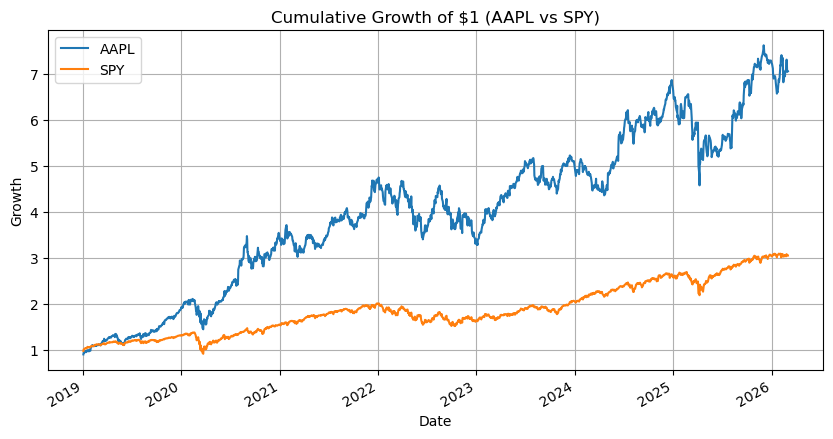

In [5]:
#Plot cumulative growth of $1

growth = (1 + returns).cumprod()

growth.plot()
plt.title("Cumulative Growth of $1 (AAPL vs SPY)")
plt.xlabel("Date")
plt.ylabel("Growth")
plt.show()

## 5. Volatility Analysis
We calculate rolling annualized volatility.

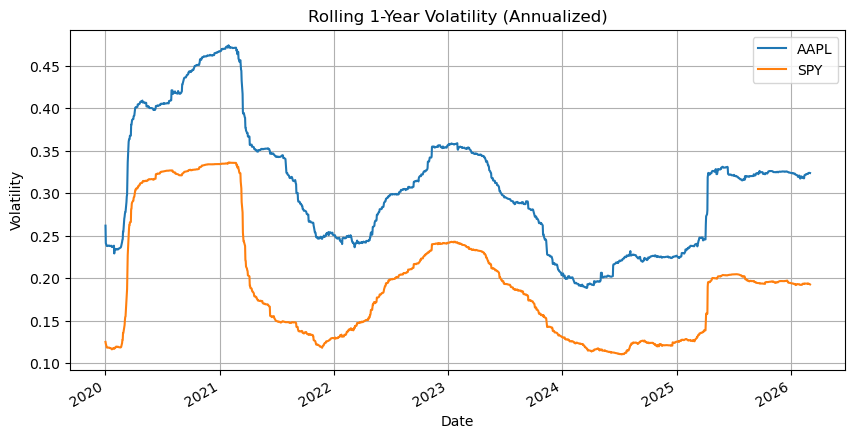

In [6]:
#Plot rolling 1 year volatility (risk)

rolling_vol = returns.rolling(252).std() * np.sqrt(252)

rolling_vol.plot()
plt.title("Rolling 1-Year Volatility (Annualized)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.show()

## 6. Risk Metrics
We compute annualized return, volatility, and Sharpe ratio.

In [7]:
#Compute the "recruiter metrics" table (return, vol, shrpe)

def annualized_return(r):
    return (1 + r).prod() ** (252 / len(r)) - 1

def annualized_vol(r):
    return r.std() * np.sqrt(252)

def sharpe(r, rf=0.0):
    return (annualized_return(r) - rf) / annualized_vol(r)

summary = pd.DataFrame({
    "Annualized Return": returns.apply(annualized_return),
    "Annualized Volatility": returns.apply(annualized_vol),
    "Sharpe (rf=0)": returns.apply(sharpe),
})

summary

,Annualized Return,Annualized Volatility,Sharpe (rf=0)
AAPL,0.314879,0.310017,1.015684
SPY,0.169102,0.196351,0.861223


In [8]:
summary.style.format({
    "Annualized Return": "{:.2%}",
    "Annualized Volatility": "{:.2%}",
    "Sharpe (rf=0)": "{:.2f}"
})

,Annualized Return,Annualized Volatility,Sharpe (rf=0)
AAPL,31.49%,31.00%,1.02
SPY,16.91%,19.64%,0.86


## 7. Correlation
We measure how closely AAPL moves with the broader market.

In [9]:
#Correlation analysis 

correlation = returns.corr()
correlation

,AAPL,SPY
AAPL,1.000000,0.773725
SPY,0.773725,1.000000


## 8. Maximum Drawdown
We evaluate worst peak-to-trough losses.

In [10]:
#Max Drawdown

def max_drawdown(r):
    cumulative = (1 + r).cumprod()
    peak = cumulative.cummax()
    drawdown = cumulative / peak - 1
    return drawdown.min()

drawdowns = returns.apply(max_drawdown)
drawdowns

AAPL   -0.333605
SPY    -0.337173
dtype: float64

## 9. Key Insights
Summary of findings.